In [ ]:
!pip -q install xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import zipfile
import urllib.request
import os
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [ ]:
import ssl
import urllib.request
import zipfile

url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
zip_file = "/content/ml-1m.zip"

# Create an unverified SSL context
unverified_context = ssl._create_unverified_context()

# Create a custom HTTPSHandler with the unverified context
https_handler = urllib.request.HTTPSHandler(context=unverified_context)

# Create an OpenerDirector and add the custom handler
opener = urllib.request.build_opener(https_handler)

# Install the opener globally
urllib.request.install_opener(opener)

# Now, urlretrieve will use the installed opener with the unverified context
urllib.request.urlretrieve(url, zip_file)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [ ]:
ratings = pd.read_csv(
    "/content/ml-1m/ratings.dat",
    sep="::",
    engine="python",
    names=["userId", "movieId", "rating", "timestamp"],
    encoding="latin-1"
)

movies = pd.read_csv(
    "/content/ml-1m/movies.dat",
    sep="::",
    engine="python",
    names=["movieId", "title", "genres"],
    encoding="latin-1"
)

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

ratings.head()

Ratings shape: (1000209, 4)
Movies shape: (3883, 3)


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
print("Number of users:",ratings["userId"].nunique())
print("Number of movies:",ratings["movieId"].nunique())
print("Number of ratings",len(ratings))
print("Average rating:",ratings["rating"].mean())
print("\nRating values:")
print(sorted(ratings["rating"].unique()))

Number of users: 6040
Number of movies: 3706
Number of ratings 1000209
Average rating: 3.581564453029317

Rating values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:
print("Missing values in ratings:")
print(ratings.isnull().sum())
print("\nMissing values in movies:")
print(movies.isnull().sum())


Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64


In [ ]:
print("Duplicate values in ratings:")
print(ratings.duplicated().sum())
print("\nDuplicate values in movies:")
print(movies.duplicated().sum())

Duplicate values in ratings:
0

Duplicate values in movies:
0


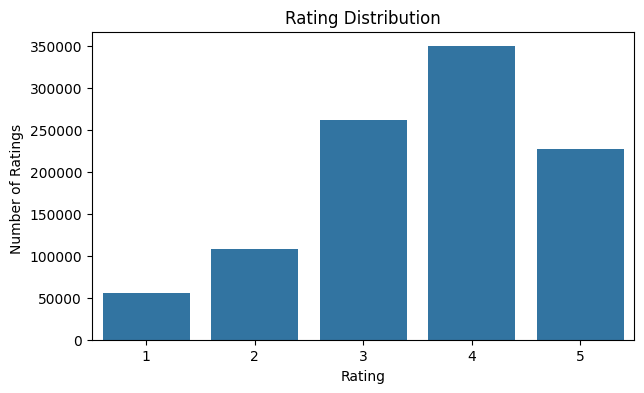

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x="rating",data=ratings)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings ")
plt.show()


In [ ]:
#For recommendation, we need to know whether a movie is **relevant** to the user.

#- Rating ≥ 4 → relevant = 1
#- Rating < 4 → relevant = 0
ratings["relevant"] = (ratings["rating"] >= 4).astype(int)

print(ratings[["rating", "relevant"]].head(10))
print("\nRelevant movie percentage:", ratings["relevant"].mean() * 100)


   rating  relevant
0       5         1
1       3         0
2       3         0
3       4         1
4       5         1
5       3         0
6       5         1
7       5         1
8       4         1
9       4         1

Relevant movie percentage: 57.516079139459855


In [ ]:
ratings = ratings.sort_values("timestamp")

split = int(len(ratings) * 0.80)

train = ratings.iloc[:split].copy()
test = ratings.iloc[split:].copy()

print("Training rows:", len(train))
print("Testing rows :", len(test))

Training rows: 800167
Testing rows : 200042


In [ ]:
user_features = train.groupby("userId").agg(
    user_rating_count=("rating", "count"),
    user_avg_rating=("rating", "mean")
).reset_index()

user_features.head()

,userId,user_rating_count,user_avg_rating
0,635,31,4.322581
1,636,86,4.058140
2,637,377,3.755968
3,638,114,4.175439
4,639,79,3.696203


In [ ]:
movie_features = train.groupby("movieId").agg(
    movie_rating_count=("rating", "count"),
    movie_avg_rating=("rating", "mean")
).reset_index()

movie_features.head()

,movieId,movie_rating_count,movie_avg_rating
0,1,1750,4.145714
1,2,566,3.197880
2,3,382,3.023560
3,4,134,2.701493
4,5,237,2.995781


In [ ]:
genre_dummies = movies["genres"].str.get_dummies(sep="|")
genre_dummies["movieId"] = movies["movieId"].values

genre_dummies.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,movieId
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,3
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,5


In [ ]:
train_data = train[["userId", "movieId", "rating", "relevant"]].copy()

train_data = train_data.merge(user_features, on="userId", how="left")
train_data = train_data.merge(movie_features, on="movieId", how="left")
train_data = train_data.merge(genre_dummies, on="movieId", how="left")

train_data = train_data.fillna(0)

train_data.head()

,userId,movieId,rating,relevant,user_rating_count,user_avg_rating,movie_rating_count,movie_avg_rating,Action,Adventure,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,6040,858,4,1,318,3.544025,1874,4.517609,1,0,...,0,0,0,0,0,0,0,0,0,0
1,6040,593,5,1,318,3.544025,2151,4.359833,0,0,...,0,0,0,0,0,0,0,1,0,0
2,6040,2384,4,1,318,3.544025,409,3.278729,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6040,1961,4,1,318,3.544025,1086,4.048803,0,0,...,0,0,0,0,0,0,0,0,0,0
4,6040,2019,5,1,318,3.544025,517,4.578337,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
basic_features = [
    "user_rating_count",
    "user_avg_rating",
    "movie_rating_count",
    "movie_avg_rating"
]

genre_features = list(genre_dummies.columns)
genre_features.remove("movieId")

features = basic_features + genre_features

X = train_data[features]
y = train_data["relevant"]

print("Number of features:", len(features))
print("X shape:", X.shape)

Number of features: 22
X shape: (800167, 22)


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (640133, 22)
X_valid: (160034, 22)


In [ ]:
baseline_score = train_data["movie_avg_rating"] / 5

baseline_prediction = (baseline_score >= 0.8).astype(int)

print("Baseline created.")

Baseline created.


In [ ]:
xgb_model=XGBClassifier(n_estimators=100,
                        max_depth=5,
                        learning_rate=0.1,
                        random_state=42,
                        eval_metric="logloss"
                        )
xgb_model.fit(X_train,y_train)
xgb_prediction=xgb_model.predict(X_valid)
xgb_probability=xgb_model.predict_proba(X_valid)[:,1]
print("XGBoost training completed")

XGBoost training completed


In [ ]:
lgb_model=LGBMClassifier(n_estimators=100,
                        num_leaves=31,
                        learning_rate=0.1,
                        random_state=42,
                         verbosity=-1
                        )
lgb_model.fit(X_train,y_train)
lgb_prediction=lgb_model.predict(X_valid)
lgb_probability=lgb_model.predict_proba(X_valid)[:,1]
print("LightGBM training completed")

LightGBM training completed


In [ ]:
xgb_train_prob=xgb_model.predict_proba(X_train)[:,1]
lgb_train_prob=lgb_model.predict_proba(X_train)[:,1]
stack_train=np.column_stack((xgb_train_prob,lgb_train_prob))
meta_model=LogisticRegression()
meta_model.fit(stack_train,y_train)
stack_valid=np.column_stack((xgb_probability,lgb_probability))
stack_probability=meta_model.predict(stack_valid)
stack_prediction=(stack_prediction>0.5).astype(int)
print("Stacking model completed")

Stacking model completed


In [ ]:
def show_metrics(name, y_true, prediction, probability):
    print("\n", name)
    print("-" * 30)
    print("Accuracy :", round(accuracy_score(y_true, prediction), 4))
    print("Precision:", round(precision_score(y_true, prediction), 4))
    print("Recall   :", round(recall_score(y_true, prediction), 4))
    print("F1 Score :", round(f1_score(y_true, prediction), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, probability), 4))

show_metrics("XGBoost", y_valid, xgb_prediction, xgb_probability)
show_metrics("LightGBM", y_valid, lgb_prediction, lgb_probability)
show_metrics("Stacking", y_valid, stack_prediction, stack_probability)


 XGBoost
------------------------------
Accuracy : 0.7221
Precision: 0.7314
Recall   : 0.8215
F1 Score : 0.7738
ROC-AUC  : 0.7873

 LightGBM
------------------------------
Accuracy : 0.7232
Precision: 0.7324
Recall   : 0.822
F1 Score : 0.7746
ROC-AUC  : 0.7882

 Stacking
------------------------------
Accuracy : 0.7233
Precision: 0.7346
Recall   : 0.817
F1 Score : 0.7736
ROC-AUC  : 0.7058


In [ ]:
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "Stacking"],
    "Accuracy": [
        accuracy_score(y_valid, xgb_prediction),
        accuracy_score(y_valid, lgb_prediction),
        accuracy_score(y_valid, stack_prediction)
    ],
    "Precision": [
        precision_score(y_valid, xgb_prediction),
        precision_score(y_valid, lgb_prediction),
        precision_score(y_valid, stack_prediction)
    ],
    "Recall": [
        recall_score(y_valid, xgb_prediction),
        recall_score(y_valid, lgb_prediction),
        recall_score(y_valid, stack_prediction)
    ],
    "F1": [
        f1_score(y_valid, xgb_prediction),
        f1_score(y_valid, lgb_prediction),
        f1_score(y_valid, stack_prediction)
    ],
    "ROC-AUC": [
        roc_auc_score(y_valid, xgb_probability),
        roc_auc_score(y_valid, lgb_probability),
        roc_auc_score(y_valid, stack_probability)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.722122,0.731365,0.821541,0.773835,0.787300
1,LightGBM,0.723203,0.732404,0.821973,0.774608,0.788227
2,Stacking,0.723284,0.734568,0.817017,0.773601,0.705787


In [ ]:
def precision_at_k(recommended, relevant, k):
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / k

def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0
    recommended = recommended[:k]
    return len(set(recommended) & set(relevant)) / len(relevant)

def ndcg_at_k(recommended, relevant, k):
    recommended = recommended[:k]

    dcg = 0
    for position, movie in enumerate(recommended, start=1):
        if movie in relevant:
            dcg += 1 / np.log2(position + 1)

    ideal_hits = min(len(relevant), k)

    if ideal_hits == 0:
        return 0

    idcg = sum(
        1 / np.log2(position + 1)
        for position in range(1, ideal_hits + 1)
    )

    return dcg / idcg

In [ ]:
# Movies the user has already watched
watched = train.groupby("userId")["movieId"].apply(set).to_dict()

def recommend_movies(user_id, model="stacking", k=10):
    # Movies not watched by the user
    watched_movies = watched.get(user_id, set())

    candidates = movies[~movies["movieId"].isin(watched_movies)].copy()

    # Add user features
    candidates = candidates.merge(user_features, on="userId", how="left") if "userId" in candidates else candidates

    # Instead, use the selected user's statistics
    user_row = user_features[user_features["userId"] == user_id]

    if len(user_row) == 0:
        return candidates.head(k)[["movieId", "title", "genres"]]

    candidates["user_rating_count"] = user_row["user_rating_count"].iloc[0]
    candidates["user_avg_rating"] = user_row["user_avg_rating"].iloc[0]

    candidates = candidates.merge(movie_features, on="movieId", how="left")
    candidates = candidates.merge(genre_dummies, on="movieId", how="left")
    candidates = candidates.fillna(0)

    X_candidates = candidates[features]

    if model == "xgboost":
        scores = xgb_model.predict_proba(X_candidates)[:, 1]
    elif model == "lightgbm":
        scores = lgb_model.predict_proba(X_candidates)[:, 1]
    else:
        p1 = xgb_model.predict_proba(X_candidates)[:, 1]
        p2 = lgb_model.predict_proba(X_candidates)[:, 1]
        scores = meta_model.predict_proba(np.column_stack((p1, p2)))[:, 1]

    candidates["score"] = scores

    return candidates.sort_values("score", ascending=False).head(k)[
        ["movieId", "title", "genres", "score"]
    ]

print("Recommendation function created.")

Recommendation function created.


In [ ]:
example_user = train["userId"].iloc[0]

recommendations = recommend_movies(
    example_user,
    model="stacking",
    k=10
)

recommendations

,movieId,title,genres,score
723,787,"Gate of Heavenly Peace, The (1995)",Documentary,0.902077
3493,3881,Bittersweet Motel (2000),Documentary,0.902077
2592,2930,Return with Honor (1998),Documentary,0.902077
3274,3656,Lured (1947),Crime,0.901447
2811,3172,Ulysses (Ulisse) (1954),Adventure,0.901142
2870,3233,Smashing Time (1967),Comedy,0.900716
1587,1830,Follow the Bitch (1998),Comedy,0.900716
2869,3232,Seven Chances (1925),Comedy,0.900716
2569,2905,Sanjuro (1962),Action|Adventure,0.900664
41,53,Lamerica (1994),Drama,0.900206


In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance.head(15)

,Feature,Importance
3,movie_avg_rating,0.642845
1,user_avg_rating,0.215524
0,user_rating_count,0.017435
14,Horror,0.012655
7,Children's,0.011706
15,Musical,0.008115
6,Animation,0.007462
5,Adventure,0.007359
17,Romance,0.007225
13,Film-Noir,0.007186


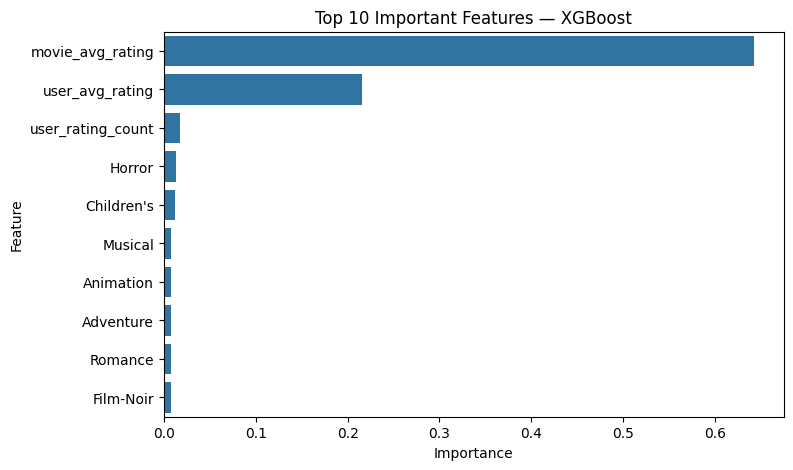

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Important Features — XGBoost")
plt.show()

In [ ]:
best_model = results.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]

print("PROJECT CONCLUSION")
print("=" * 50)
print("1. MovieLens 1M was used for movie recommendation.")
print("2. User, movie and genre features were created.")
print("3. XGBoost and LightGBM were used as boosting models.")
print("4. Stacking combined XGBoost and LightGBM.")
print("5. Precision@K, Recall@K and NDCG@K are the main recommendation metrics.")
print("6. The best classification model by ROC-AUC in this run is:", best_model)

PROJECT CONCLUSION
1. MovieLens 1M was used for movie recommendation.
2. User, movie and genre features were created.
3. XGBoost and LightGBM were used as boosting models.
4. Stacking combined XGBoost and LightGBM.
5. Precision@K, Recall@K and NDCG@K are the main recommendation metrics.
6. The best classification model by ROC-AUC in this run is: LightGBM
